# Analysis of Replication dataset and generated one

In [ ]:
import os
import glob
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance, skew, kurtosis


In [ ]:
ref_dir = "../data/replication/"
gen_dir = "../data/generated/replication/"

# Statistical Analysis of Replication Dataset

It loads the `stats_dict` from the pickle file and it loads every processed CSV into a dicionary keyed by ticker.

In [ ]:
FEATURE_COLS = ["log_adj_close"]
DATE_COL     = "date"

In [ ]:
def load_processed_universe(data_dir):
    """
    Load every CSV in data_dir into a dict keyed by ticker.
    Files are assumed to have columns DATE_COL and FEATURE_COLS.
    Variable-length series are handled naturally — no padding.
    Ticker is extracted as the first underscore-delimited token of the filename stem.
    """
    csv_files = sorted(glob.glob(os.path.join(data_dir, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")
    data = {}
    for fp in csv_files:
        stem   = Path(fp).stem                          # e.g. "AAPL_1980-12-12_2026-03-23"
        ticker = stem.split("_")[0]                     # "AAPL"
        df     = pd.read_csv(fp, parse_dates=[DATE_COL])
        df     = df[[DATE_COL] + FEATURE_COLS].copy()
        df.rename(columns={DATE_COL: "Date"}, inplace=True)
        df["Step"] = np.arange(len(df))
        data[ticker] = df
    return data

## Flatten all stock into one table
We generate an aggregate table over all samples as to perform aggregate statistics and time-specific ones.

In [ ]:
def make_long_panel(universe):
    rows = []
    for ticker, df in universe.items():
        d = df.copy()
        d["Ticker"] = ticker
        rows.append(d)
    return pd.concat(rows, axis=0, ignore_index=True)

# Aggregate distribution statistics
* mean
* std
* skewness
* excess kurtosis
* selected quantiles

In [ ]:
def summarize_global_distribution(panel):
    summary = {}
    for col in FEATURE_COLS:
        x = panel[col].dropna().to_numpy()
        summary[col] = {
            "mean":            np.mean(x),
            "std":             np.std(x, ddof=0),
            "skew":            skew(x, bias=False),
            "kurtosis_excess": kurtosis(x, fisher=True, bias=False),
            "q01":             np.quantile(x, 0.01),
            "q05":             np.quantile(x, 0.05),
            "median":          np.quantile(x, 0.50),
            "q95":             np.quantile(x, 0.95),
            "q99":             np.quantile(x, 0.99),
        }
    return pd.DataFrame(summary).T

## Two-sample comparison metrics
For each channel it compares reference and generated distributions using:
* KS statistics
* KS p-value
* Wasserstein-1 distance
* moment differences

In [ ]:
def compare_global_distributions(panel_ref, panel_gen):
    rows = []
    for col in FEATURE_COLS:
        x = panel_ref[col].dropna().to_numpy()
        y = panel_gen[col].dropna().to_numpy()
        ks_stat, ks_p = ks_2samp(x, y)
        rows.append({
            "feature":             col,
            "ref_mean":            np.mean(x),
            "gen_mean":            np.mean(y),
            "ref_std":             np.std(x, ddof=0),
            "gen_std":             np.std(y, ddof=0),
            "ref_skew":            skew(x, bias=False),
            "gen_skew":            skew(y, bias=False),
            "ref_kurtosis_excess": kurtosis(x, fisher=True, bias=False),
            "gen_kurtosis_excess": kurtosis(y, fisher=True, bias=False),
            "KS_stat":             ks_stat,
            "KS_pvalue":           ks_p,
            "Wasserstein_1":       wasserstein_distance(x, y),
        })
    return pd.DataFrame(rows)

## Pathwise stock-level statistics
For each stock/path it computes:
* mean, variance, skewness, kurtosis of `Close` log-returns
* annualized volatility

This is done to check if aggregating hide a possible path-level mismatch.

In [ ]:
def compute_pathwise_stats(universe):
    """
    Per-path moments on log_adj_close.
    T is set to the actual path length of each series.
    GBM estimates are valid when log_adj_close contains log-returns.
    """
    rows = []
    for ticker, df in universe.items():
        r  = df["log_adj_close"].dropna().to_numpy(dtype=np.float64)
        T_ = len(r)
        if T_ < 2:
            continue

        nu_hat = np.sqrt(np.sum(r ** 2) / T_)
        mu_hat = np.sum(r) / T_ + 0.5 * nu_hat ** 2

        rows.append({
            "Ticker":              ticker,
            "n_obs":               T_,
            "mean_log_ret":        np.mean(r),
            "var_log_ret":         np.var(r, ddof=0),
            "skew_log_ret":        skew(r, bias=False),
            "kurt_log_ret_excess": kurtosis(r, fisher=True, bias=False),
            "annualized_vol":      nu_hat,
            "annualized_drift":    mu_hat,
        })
    return pd.DataFrame(rows)

In [ ]:
def compare_pathwise_stats(stats_ref, stats_gen):
    cols = [c for c in stats_ref.columns if c not in ("Ticker", "n_obs")]
    rows = []
    for col in cols:
        x = stats_ref[col].dropna().to_numpy()
        y = stats_gen[col].dropna().to_numpy()
        ks_stat, ks_p = ks_2samp(x, y)
        rows.append({
            "metric":        col,
            "ref_mean":      np.mean(x),
            "gen_mean":      np.mean(y),
            "ref_std":       np.std(x, ddof=0),
            "gen_std":       np.std(y, ddof=0),
            "KS_stat":       ks_stat,
            "KS_pvalue":     ks_p,
            "Wasserstein_1": wasserstein_distance(x, y),
        })
    return pd.DataFrame(rows)


## Step-specific statistics
We are comparing the relative step, which is usually better that comparing calendar dates. For each step across all stocks we compute:
* mean
* std
* 5th percentile
*95th percentile

In [ ]:
def stepwise_summary(panel):
    out = (
        panel.groupby("Step")[FEATURE_COLS]
        .agg(["mean", "std",
              lambda x: np.quantile(x, 0.05),
              lambda x: np.quantile(x, 0.95)])
    )
    out.columns = [
        f"{col}_{s if isinstance(s, str) else ('q05' if i % 4 == 2 else 'q95')}"
        for i, (col, s) in enumerate(out.columns)
    ]
    out["n_series"] = panel.groupby("Step")[FEATURE_COLS[0]].count().values
    return out.reset_index()

# Date-specific statistics
Suppose that both dataset use same/similar statistics

In [ ]:
def datewise_summary(panel):
    out = (
        panel.groupby("Date")[FEATURE_COLS]
        .agg(["mean", "std",
              lambda x: np.quantile(x, 0.05),
              lambda x: np.quantile(x, 0.95)])
    )
    out.columns = [
        f"{col}_{s if isinstance(s, str) else ('q05' if i % 4 == 2 else 'q95')}"
        for i, (col, s) in enumerate(out.columns)
    ]
    out["n_series"] = panel.groupby("Date")[FEATURE_COLS[0]].count().values
    return out.reset_index()

# Distribution plots
We are plotting as to see:
* wider tails
* shifted mean
* over-dispersion
* asymmetry

In [ ]:
def plot_feature_histograms(panel_ref, panel_gen, bins=100):
    fig, axes = plt.subplots(len(FEATURE_COLS), 1,
                             figsize=(10, 3 * len(FEATURE_COLS)))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, FEATURE_COLS):
        ax.hist(panel_ref[col].dropna(), bins=bins, density=True,
                alpha=0.5, label="Reference")
        ax.hist(panel_gen[col].dropna(), bins=bins, density=True,
                alpha=0.5, label="Generated")
        ax.set_title(f"Distribution comparison: {col}")
        ax.legend()
    plt.tight_layout(); plt.show()

## ECDF plots
It plots empirical CDFs for each feature. This is visually tied to the KS statistic: the KS distance is the maximum gap between these two curves.

In [ ]:
def plot_ecdf_comparison(panel_ref, panel_gen):
    fig, axes = plt.subplots(len(FEATURE_COLS), 1,
                             figsize=(10, 3 * len(FEATURE_COLS)))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, FEATURE_COLS):
        x = np.sort(panel_ref[col].dropna().to_numpy())
        y = np.sort(panel_gen[col].dropna().to_numpy())
        ax.plot(x, np.arange(1, len(x) + 1) / len(x), label="Reference")
        ax.plot(y, np.arange(1, len(y) + 1) / len(y), label="Generated")
        ax.set_title(f"ECDF comparison: {col}")
        ax.legend()
    plt.tight_layout(); plt.show()

## Pathwise metric plots
We are plotting a stock-level distribution of:
* Annualized drift
* annualized volatility
* mean/variance/skew/kurtosis of returns

In [ ]:
def plot_pathwise_metric_histograms(stats_ref, stats_gen):
    metric_cols = [c for c in stats_ref.columns if c not in ("Ticker", "n_obs")]
    fig, axes = plt.subplots(len(metric_cols), 1,
                             figsize=(10, 3 * len(metric_cols)))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, metric_cols):
        ax.hist(stats_ref[col].dropna(), bins=50, density=True,
                alpha=0.5, label="Reference")
        ax.hist(stats_gen[col].dropna(), bins=50, density=True,
                alpha=0.5, label="Generated")
        ax.set_title(f"Pathwise distribution: {col}")
        ax.legend()
    plt.tight_layout(); plt.show()


## Time-step graph with uncertainty bands

In [ ]:
def plot_stepwise_bands(step_ref, step_gen, feature="log_adj_close"):
    col_mean = f"{feature}_mean"
    col_q05  = f"{feature}_q05"
    col_q95  = f"{feature}_q95"

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(step_ref["Step"], step_ref[col_mean], label="Reference mean")
    ax.fill_between(step_ref["Step"],
                    step_ref[col_q05], step_ref[col_q95], alpha=0.2)
    ax.plot(step_gen["Step"], step_gen[col_mean], label="Generated mean")
    ax.fill_between(step_gen["Step"],
                    step_gen[col_q05], step_gen[col_q95], alpha=0.2)
    ax.set_title(f"Stepwise comparison with 5%–95% band: {feature}")
    ax.set_xlabel("Step"); ax.set_ylabel(feature); ax.legend()
    plt.tight_layout(); plt.show()


# Run the comparison

In [ ]:
def evaluate_universes(ref_dir, gen_dir):
    ref_universe = load_processed_universe(ref_dir)
    gen_universe = load_processed_universe(gen_dir)

    panel_ref = make_long_panel(ref_universe)
    panel_gen = make_long_panel(gen_universe)

    global_ref = summarize_global_distribution(panel_ref)
    global_gen = summarize_global_distribution(panel_gen)
    global_cmp = compare_global_distributions(panel_ref, panel_gen)

    path_ref = compute_pathwise_stats(ref_universe)
    path_gen = compute_pathwise_stats(gen_universe)
    path_cmp = compare_pathwise_stats(path_ref, path_gen)

    step_ref = stepwise_summary(panel_ref)
    step_gen = stepwise_summary(panel_gen)

    print("GLOBAL REFERENCE SUMMARY");  display(global_ref)
    print("GLOBAL GENERATED SUMMARY");  display(global_gen)
    print("GLOBAL COMPARISON");         display(global_cmp)
    print("PATHWISE COMPARISON");       display(path_cmp)

    plot_feature_histograms(panel_ref, panel_gen)
    plot_ecdf_comparison(panel_ref, panel_gen)
    plot_pathwise_metric_histograms(path_ref, path_gen)
    plot_stepwise_bands(step_ref, step_gen, feature="log_adj_close")

    return dict(
        panel_ref=panel_ref, panel_gen=panel_gen,
        global_ref=global_ref, global_gen=global_gen, global_cmp=global_cmp,
        path_ref=path_ref, path_gen=path_gen, path_cmp=path_cmp,
        step_ref=step_ref, step_gen=step_gen,
    )

In [ ]:
def evaluate_ref_only(ref_dir):
    ref_universe = load_processed_universe(ref_dir)
    panel_ref    = make_long_panel(ref_universe)
    global_ref   = summarize_global_distribution(panel_ref)
    path_ref     = compute_pathwise_stats(ref_universe)
    step_ref     = stepwise_summary(panel_ref)

    print("GLOBAL REFERENCE SUMMARY"); display(global_ref)

    return dict(panel_ref=panel_ref, global_ref=global_ref,
                path_ref=path_ref, step_ref=step_ref)


# Evaluation

In [ ]:
results = evaluate_ref_only(ref_dir=ref_dir)


GLOBAL REFERENCE SUMMARY


,mean,std,skew,kurtosis_excess,q01,q05,median,q95,q99
Open,0.000037,0.009225,-0.006217,1.252586,-0.023988,-0.015276,0.000049,0.015318,0.023994
High,0.014406,0.015618,1.055500,2.049867,-0.014338,-0.005694,0.011544,0.044197,0.063379
Low,-0.014197,0.015610,-1.065088,2.049736,-0.063231,-0.043992,-0.011300,0.005839,0.014299
Close,0.000160,0.018461,-0.008836,1.256982,-0.047992,-0.030516,0.000205,0.030707,0.048132
Volume,0.000402,0.211890,0.037607,0.028382,-0.487574,-0.345868,-0.000881,0.350763,0.500422


{'panel_ref':               Date      Open      High       Low     Close    Volume  \
0       1986-01-02 -0.016430 -0.008859 -0.016684 -0.013646 -0.083195   
1       1986-01-03  0.011090  0.029075 -0.005974  0.028075  0.269155   
2       1986-01-06 -0.010843  0.011720 -0.024141 -0.002795  0.008605   
3       1986-01-07 -0.002335  0.016171 -0.019562 -0.017223  0.019315   
4       1986-01-08 -0.004445  0.012708 -0.010693  0.007176  0.130480   
...            ...       ...       ...       ...       ...       ...   
2015995 2024-08-15 -0.020122  0.005045 -0.020370 -0.003225 -0.513521   
2015996 2024-08-16  0.015724  0.037631  0.008777  0.016358  0.076706   
2015997 2024-08-19  0.005217  0.012779 -0.025829 -0.012940  0.154496   
2015998 2024-08-20 -0.012047  0.002521 -0.013580 -0.003228  0.041828   
2015999 2024-08-21 -0.008098  0.014648 -0.010576 -0.008584 -0.110430   

            Ticker   Step  
0        FAKE_0001      0  
1        FAKE_0001      1  
2        FAKE_0001      2  
3        

GLOBAL REFERENCE SUMMARY


,mean,std,skew,kurtosis_excess,q01,q05,median,q95,q99
Open,0.000037,0.009225,-0.006217,1.252586,-0.023988,-0.015276,0.000049,0.015318,0.023994
High,0.014406,0.015618,1.055500,2.049867,-0.014338,-0.005694,0.011544,0.044197,0.063379
Low,-0.014197,0.015610,-1.065088,2.049736,-0.063231,-0.043992,-0.011300,0.005839,0.014299
Close,0.000160,0.018461,-0.008836,1.256982,-0.047992,-0.030516,0.000205,0.030707,0.048132
Volume,0.000402,0.211890,0.037607,0.028382,-0.487574,-0.345868,-0.000881,0.350763,0.500422


GLOBAL GENERATED SUMMARY


,mean,std,skew,kurtosis_excess,q01,q05,median,q95,q99
Open,-3.043265,17.625818,-0.051276,-0.387600,-40.774571,-33.153356,-2.222269,26.705916,35.703699
High,-6.179082,21.699244,-0.258229,-0.833133,-52.310220,-43.001555,-3.807903,25.689225,33.371439
Low,6.875419,22.044511,0.009544,-1.056137,-35.606195,-27.231964,5.763759,40.635121,48.237019
Close,-1.111570,25.796924,-0.068220,-0.844795,-52.463289,-43.285420,-1.398417,39.354609,48.323972
Volume,-0.868640,7.334283,-0.156261,0.160380,-19.022240,-13.509640,-0.682607,10.705612,16.040254


GLOBAL COMPARISON


,feature,ref_mean,gen_mean,ref_std,gen_std,ref_skew,gen_skew,ref_kurtosis_excess,gen_kurtosis_excess,KS_stat,KS_pvalue,Wasserstein_1
0,Open,0.000037,-3.043265,0.009225,17.625818,-0.006217,-0.051276,1.252586,-0.387600,0.552791,0.0,14.231360
1,High,0.014406,-6.179082,0.015618,21.699244,1.055500,-0.258229,2.049867,-0.833133,0.558675,0.0,18.302536
2,Low,-0.014197,6.875419,0.015610,22.044511,-1.065088,0.009544,2.049736,-1.056137,0.569946,0.0,19.514609
3,Close,0.000160,-1.111570,0.018461,25.796924,-0.008836,-0.068220,1.256982,-0.844795,0.521788,0.0,21.348682
4,Volume,0.000402,-0.868640,0.211890,7.334283,0.037607,-0.156261,0.028382,0.160380,0.503467,0.0,5.652069


PATHWISE COMPARISON


,metric,ref_mean,gen_mean,ref_std,gen_std,KS_stat,KS_pvalue,Wasserstein_1
0,mean_close_ret,0.000160,-1.111570,0.000255,1.715284,0.73,5.882330e-35,1.671096
1,var_close_ret,0.000341,662.539112,0.000220,82.330065,1.00,4.809714e-82,662.538771
2,skew_close_ret,0.001594,-0.064831,0.023470,0.076640,0.60,8.850025e-23,0.070617
3,kurt_close_ret_excess,-0.000043,-0.852458,0.051945,0.107868,1.00,4.809714e-82,0.852415
4,annualized_vol_close,0.275402,64.683870,0.100228,4.038986,1.00,4.809714e-82,64.408468
5,annualized_drift_close,0.083305,2093.155338,0.058141,260.879116,1.00,4.809714e-82,2093.072033


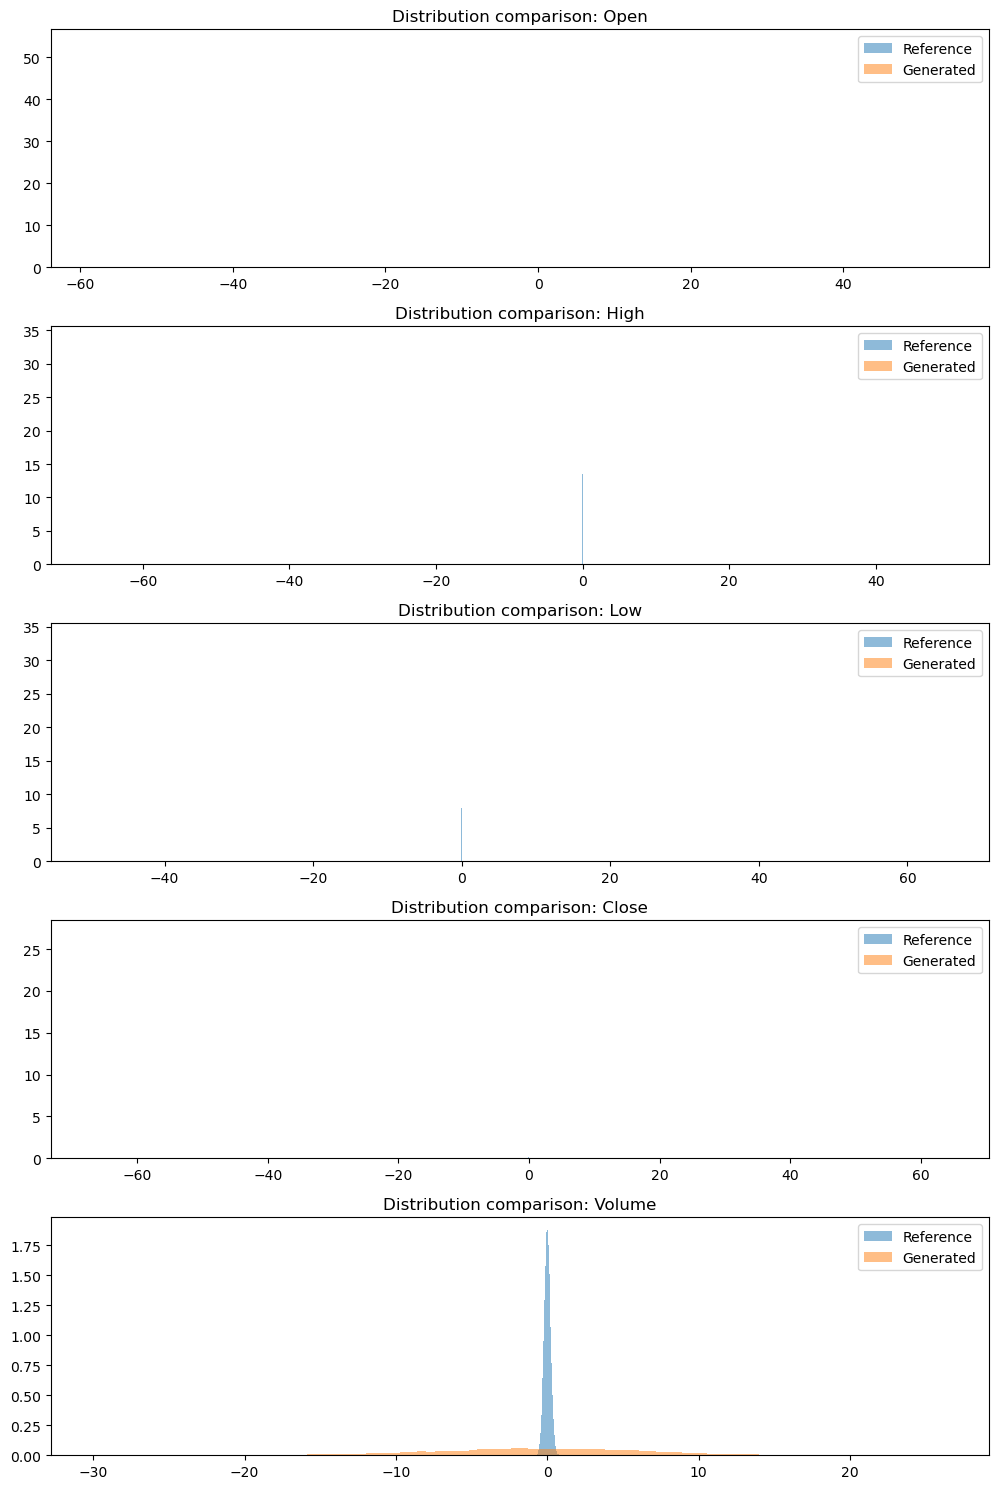

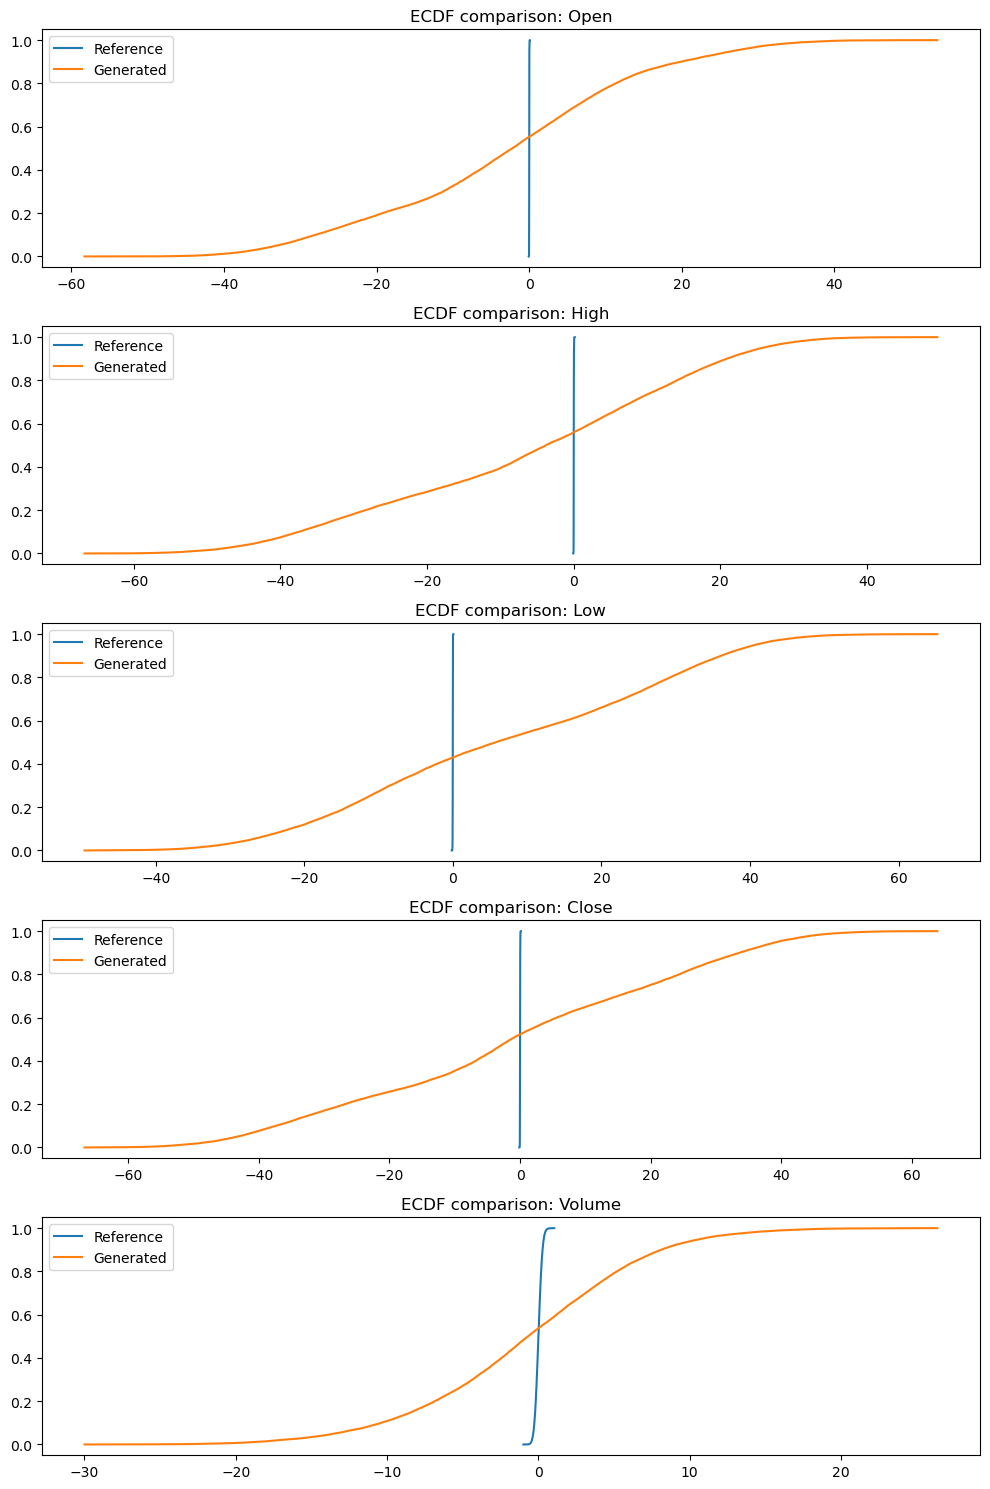

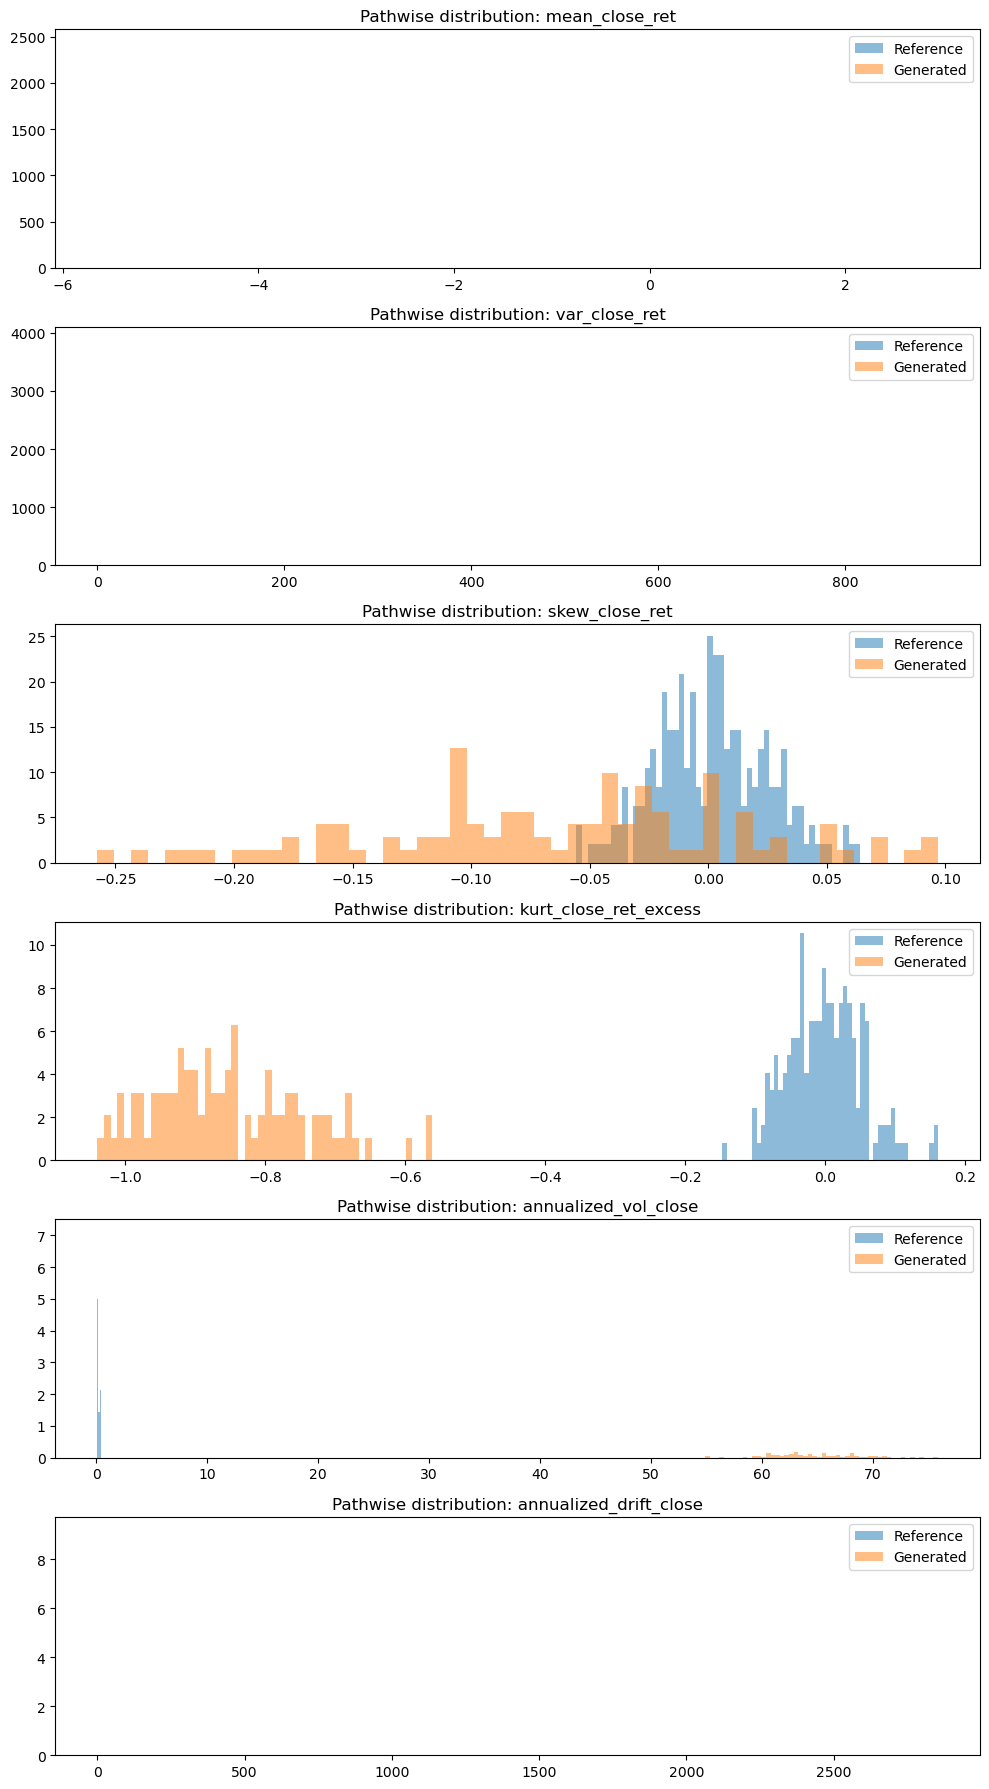

KeyError: 'Close_q05'

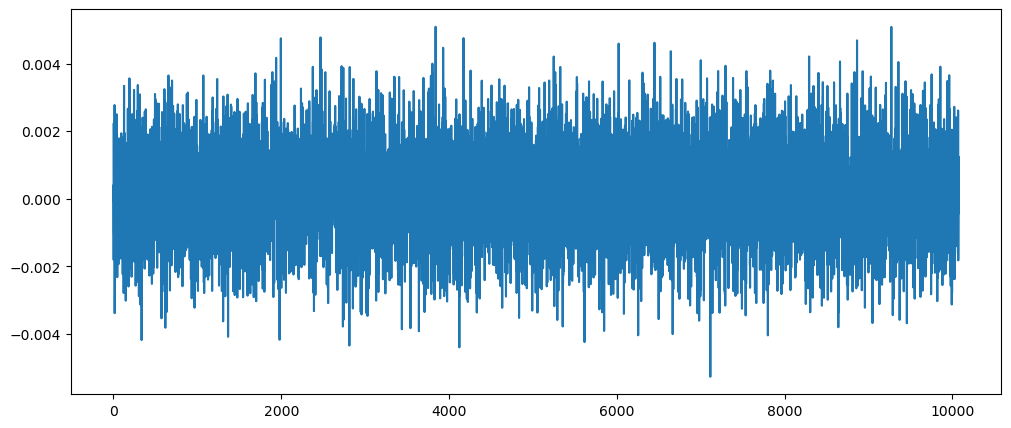

In [ ]:
results = evaluate_universes(ref_dir=ref_dir, gen_dir=gen_dir)